# 🤚 Hand Gesture Recognition — CNN Approach
**SkillCraft Technology Internship — Task 04**

**Objective:** Classify 10 hand gestures from Leap Motion infrared images using a Convolutional Neural Network.

**Dataset:** LeapGestRecog — 10 subjects × 10 gestures × 200 images = **20,000 images**

| Label | Gesture | Label | Gesture |
|-------|---------|-------|--------|
| 01_palm | Palm | 06_index | Index Finger |
| 02_l | L Shape | 07_ok | OK Sign |
| 03_fist | Fist | 08_palm_moved | Palm Moved |
| 04_fist_moved | Fist Moved | 09_c | C Shape |
| 05_thumb | Thumb | 10_down | Down |

## Step 1: Install & Import Libraries

In [1]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn tqdm numpy pandas

In [2]:
import sys
!{sys.executable} -m pip uninstall keras tensorflow -y
!{sys.executable} -m pip install tensorflow==2.21.0 tf_keras
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'✅ Libraries imported!')
print(f'GPU available: {gpus if gpus else "No GPU — using CPU"}')

Found existing installation: keras 3.14.1
Uninstalling keras-3.14.1:
  Successfully uninstalled keras-3.14.1
Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Using cached keras-3.14.1-py3-none-any.whl (1.6 MB)

   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
   ---------------------------------------- 0/2 [keras]
  

## Step 2: Configuration

In [3]:
# =============================================
# SET YOUR DATASET PATH HERE
# =============================================
DATASET_PATH = r'C:\Users\Jatin\OneDrive\Desktop\INTERNSHIP\SCT_ML_4\leapGestRecog'

# Image settings
IMG_HEIGHT   = 128
IMG_WIDTH    = 128
CHANNELS     = 1       # Grayscale
BATCH_SIZE   = 32
EPOCHS       = 30
NUM_CLASSES  = 10

GESTURE_LABELS = {
    '01_palm'       : 'Palm',
    '02_l'          : 'L Shape',
    '03_fist'       : 'Fist',
    '04_fist_moved' : 'Fist Moved',
    '05_thumb'      : 'Thumb',
    '06_index'      : 'Index',
    '07_ok'         : 'OK',
    '08_palm_moved' : 'Palm Moved',
    '09_c'          : 'C Shape',
    '10_down'       : 'Down'
}

print(f'Image size   : {IMG_HEIGHT}x{IMG_WIDTH} (grayscale)')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Classes      : {NUM_CLASSES}')

Image size   : 128x128 (grayscale)
Batch size   : 32
Max epochs   : 30
Classes      : 10


## Step 3: Load & Explore Dataset

In [4]:
# Verify path
print('Path exists:', os.path.exists(DATASET_PATH))
print('Contents:', sorted(os.listdir(DATASET_PATH)))

Path exists: True
Contents: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


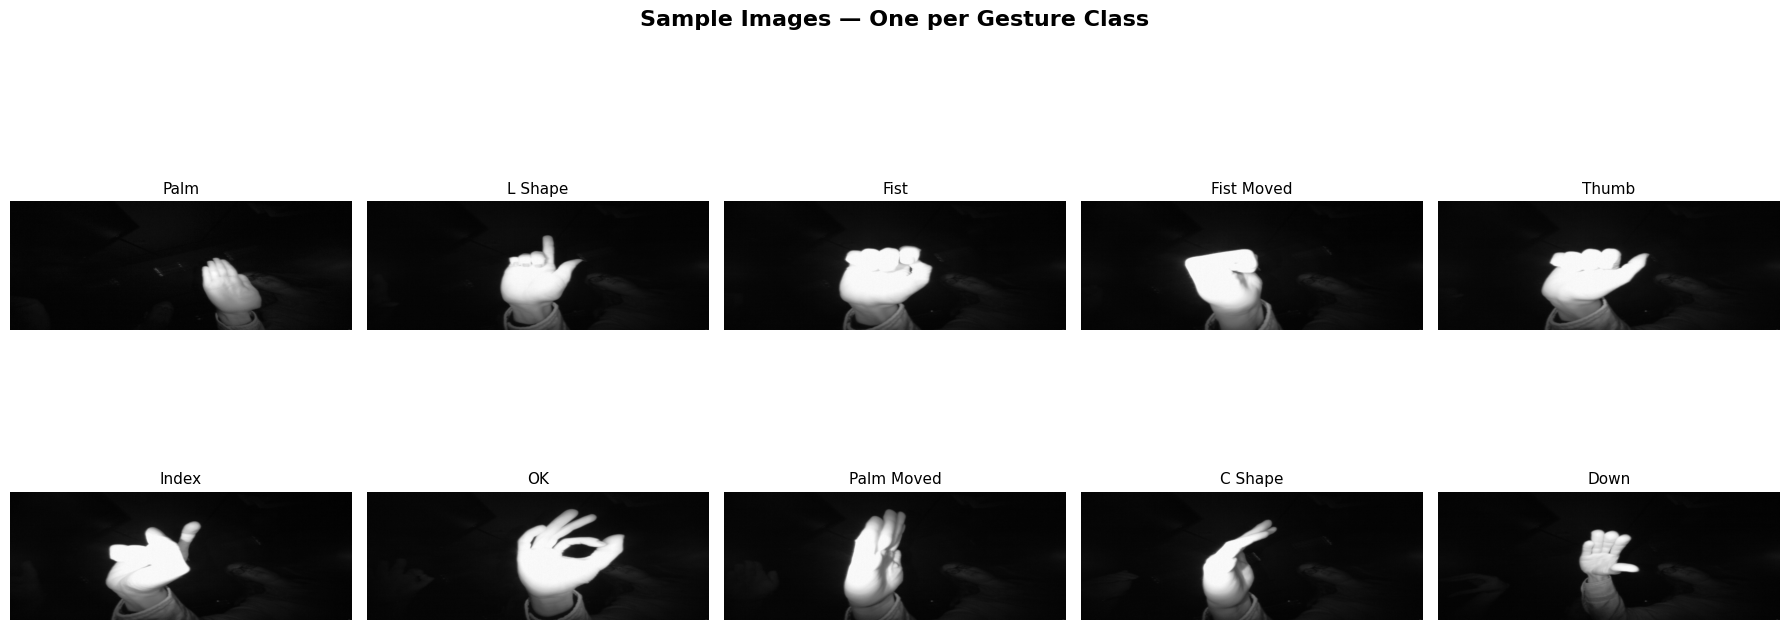

✅ Sample images displayed


In [5]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sample Images — One per Gesture Class', fontsize=16, fontweight='bold')

subject_0 = sorted(os.listdir(DATASET_PATH))[0]
gestures  = sorted(os.listdir(os.path.join(DATASET_PATH, subject_0)))

for idx, gesture in enumerate(gestures[:10]):
    ax = axes[idx // 5][idx % 5]
    gesture_path = os.path.join(DATASET_PATH, subject_0, gesture)
    img_file = os.listdir(gesture_path)[0]
    img = cv2.imread(os.path.join(gesture_path, img_file), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(GESTURE_LABELS.get(gesture, gesture), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_gestures.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images displayed')

## Step 4: Load All Images into Memory

In [6]:
# Load all images as numpy arrays
# ~20k images at 128x128 grayscale ≈ 390 MB RAM

X = []
y = []

subjects = sorted([d for d in os.listdir(DATASET_PATH)
                   if os.path.isdir(os.path.join(DATASET_PATH, d))])

for subject in tqdm(subjects, desc='Loading subjects'):
    subject_path = os.path.join(DATASET_PATH, subject)
    gestures = sorted([d for d in os.listdir(subject_path)
                       if os.path.isdir(os.path.join(subject_path, d))])

    for gesture in gestures:
        gesture_path = os.path.join(subject_path, gesture)
        images = [f for f in os.listdir(gesture_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_file in images:
            img_path = os.path.join(gesture_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            X.append(img)
            y.append(gesture)

X = np.array(X, dtype='float32')
y = np.array(y)

print(f'\n✅ Dataset loaded!')
print(f'X shape : {X.shape}  →  (samples, height, width)')
print(f'y shape : {y.shape}')
print(f'Classes : {np.unique(y)}')

Loading subjects: 100%|██████████| 10/10 [00:42<00:00,  4.25s/it]



✅ Dataset loaded!
X shape : (20000, 128, 128)  →  (samples, height, width)
y shape : (20000,)
Classes : ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


X shape after reshape : (20000, 128, 128, 1)
y_cat shape           : (20000, 10)


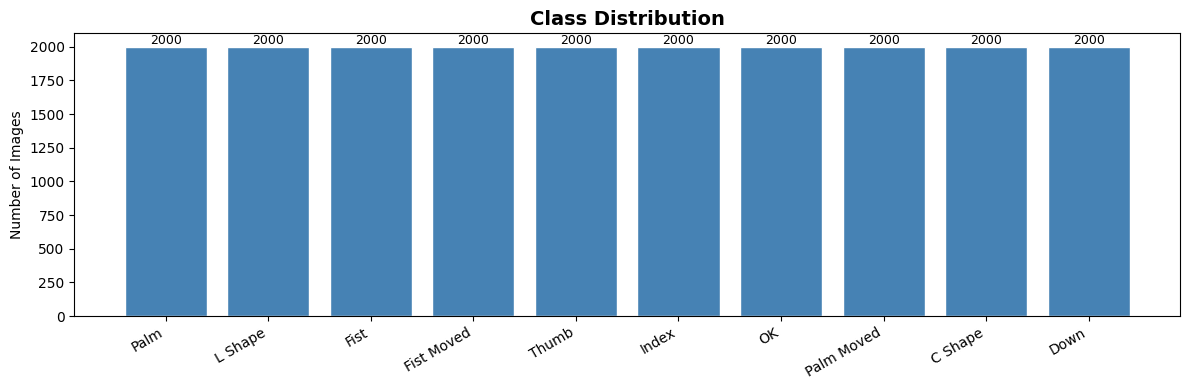

In [7]:
# Normalize pixel values to [0, 1] and add channel dim
X = X / 255.0
X = X.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)   # (N, 128, 128, 1)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded, NUM_CLASSES)  # one-hot

print(f'X shape after reshape : {X.shape}')
print(f'y_cat shape           : {y_cat.shape}')

# Class distribution plot
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(12, 4))
bars = plt.bar([GESTURE_LABELS.get(g, g) for g in unique], counts,
               color='steelblue', edgecolor='white')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Train / Validation / Test Split

In [8]:
# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=42, stratify=y_encoded)

y_temp_encoded = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp_encoded)

print(f'Train   : {X_train.shape[0]} samples')
print(f'Val     : {X_val.shape[0]} samples')
print(f'Test    : {X_test.shape[0]} samples')

Train   : 14000 samples
Val     : 3000 samples
Test    : 3000 samples


## Step 6: Build the CNN Model

In [9]:
def build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=NUM_CLASSES):
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,679,786 (33.11 MB)

 Trainable params: 8,678,826 (33.11 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 7: Train the Model

In [10]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_gesture_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

print('\n✅ Training complete!')

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.7576 - loss: 0.7981
Epoch 1: val_accuracy improved from None to 0.12000, saving model to best_gesture_model.keras

Epoch 1: finished saving model to best_gesture_model.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 270s 607ms/step - accuracy: 0.9100 - loss: 0.3086 - val_accuracy: 0.1200 - val_loss: 6.1698 - learning_rate: 0.0010
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9961 - loss: 0.0262
Epoch 2: val_accuracy improved from 0.12000 to 0.99500, saving model to best_gesture_model.keras

Epoch 2: finished saving model to best_gesture_model.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 255s 582ms/step - accuracy: 0.9970 - loss: 0.0201 - val_accuracy: 0.9950 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9977 - loss: 0.0141
Epoch 3: val_accuracy improved from 0.99500 to 1.00000, saving model to best_gesture_model.keras

Epoch 3: finished saving model to bes

## Step 8: Training Curves

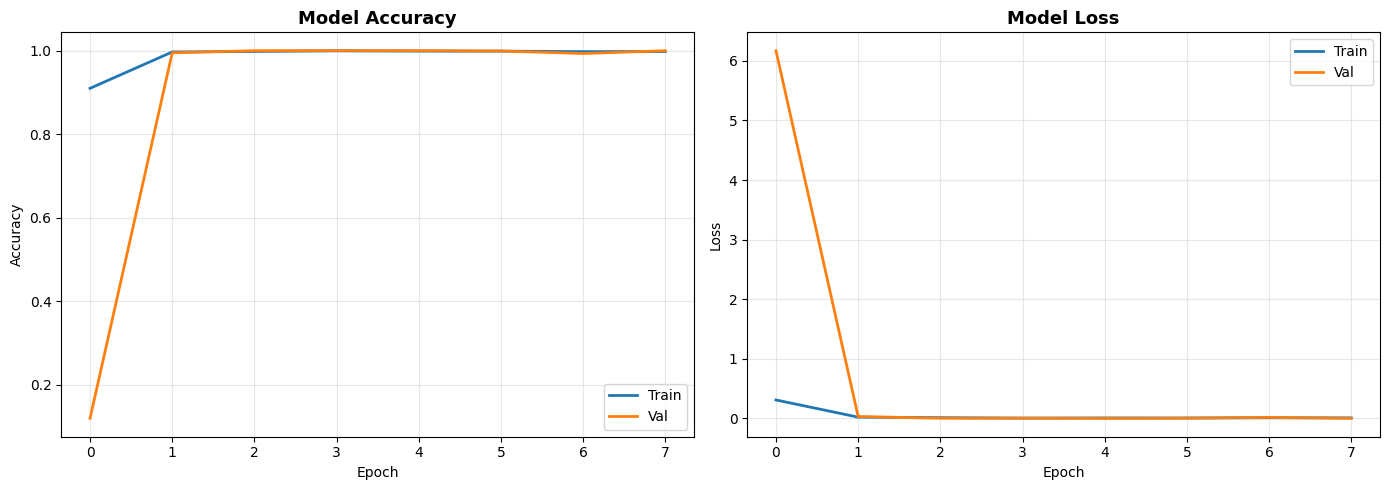

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Evaluate on Test Set

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

Test Accuracy : 100.00%
Test Loss     : 0.0021


In [13]:
# Classification Report
y_pred      = np.argmax(model.predict(X_test), axis=1)
y_true      = np.argmax(y_test, axis=1)
target_names = [GESTURE_LABELS.get(cls, cls) for cls in le.classes_]

print('Classification Report\n')
print(classification_report(y_true, y_pred, target_names=target_names))

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step
Classification Report

              precision    recall  f1-score   support

        Palm       1.00      1.00      1.00       300
     L Shape       1.00      1.00      1.00       300
        Fist       1.00      1.00      1.00       300
  Fist Moved       1.00      1.00      1.00       300
       Thumb       1.00      1.00      1.00       300
       Index       1.00      1.00      1.00       300
          OK       1.00      1.00      1.00       300
  Palm Moved       1.00      1.00      1.00       300
     C Shape       1.00      1.00      1.00       300
        Down       1.00      1.00      1.00       300

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



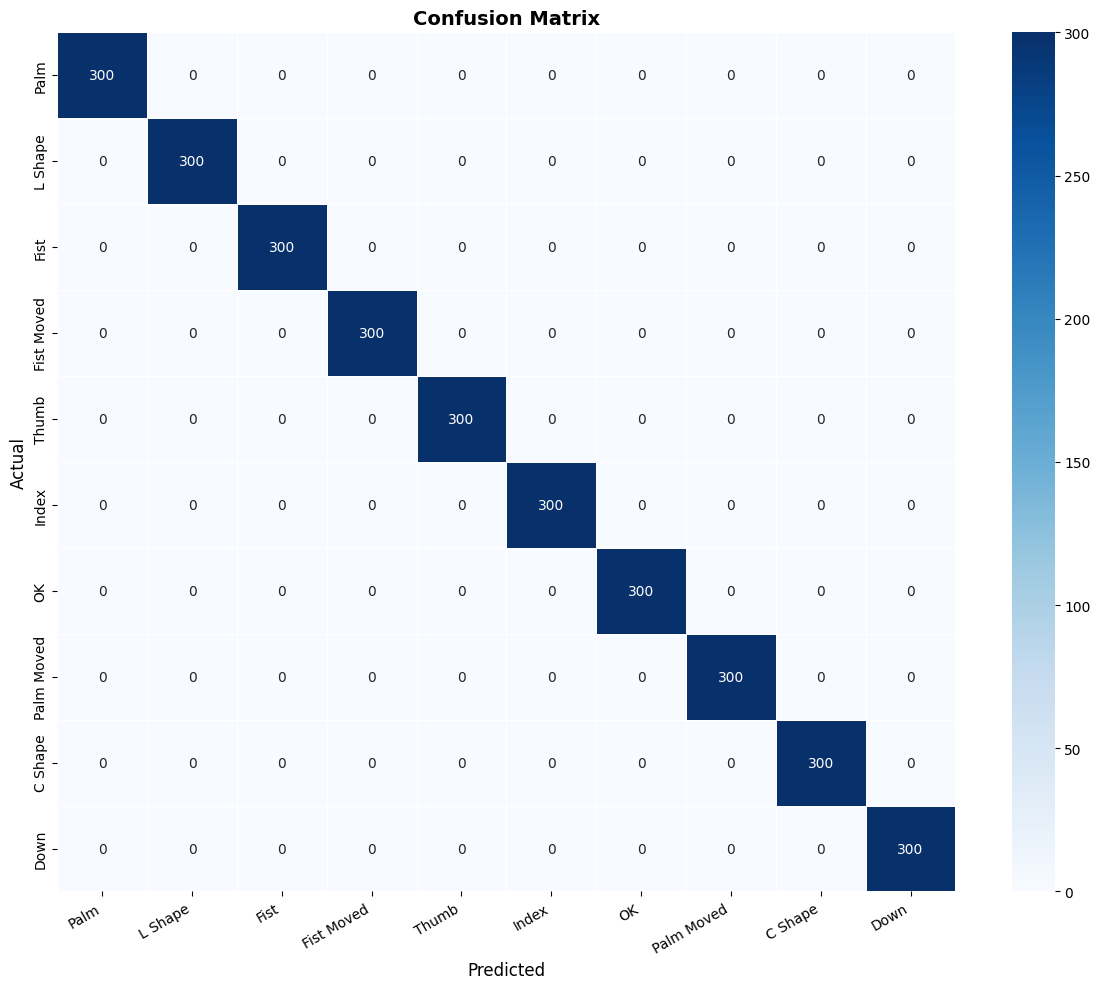

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

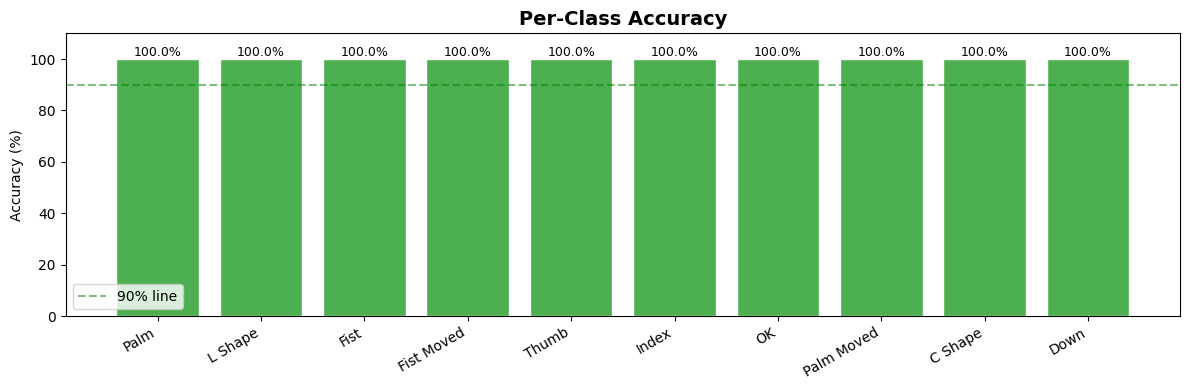

In [15]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 4))
bars = plt.bar(target_names, per_class_acc * 100,
               color=['#4CAF50' if a >= 0.9 else '#FF9800' if a >= 0.75 else '#F44336'
                      for a in per_class_acc], edgecolor='white')
plt.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% line')
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc*100:.1f}%', ha='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Predict on a Single Image

In [16]:
def predict_gesture(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img_norm = img_resized / 255.0
    img_input = img_norm.reshape(1, IMG_HEIGHT, IMG_WIDTH, 1)

    proba = model.predict(img_input, verbose=0)[0]
    pred_idx = np.argmax(proba)
    gesture_code = le.inverse_transform([pred_idx])[0]
    gesture_name = GESTURE_LABELS.get(gesture_code, gesture_code)
    confidence = proba[pred_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted: {gesture_name}\nConfidence: {confidence:.1f}%', fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f'Gesture    : {gesture_name}')
    print(f'Confidence : {confidence:.1f}%')

# ---- Test on any image ----
# predict_gesture(r'path\to\image.png')
print('✅ predict_gesture() ready! Uncomment last line to test.')

✅ predict_gesture() ready! Uncomment last line to test.


## Step 11: Live Webcam Demo (Optional)

In [17]:
# Press 'q' to quit
def run_webcam_demo():
    cap = cv2.VideoCapture(0)
    print('Webcam started — press Q to quit')

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (IMG_WIDTH, IMG_HEIGHT))
        norm = resized / 255.0
        inp = norm.reshape(1, IMG_HEIGHT, IMG_WIDTH, 1)

        proba = model.predict(inp, verbose=0)[0]
        pred_idx = np.argmax(proba)
        gesture_code = le.inverse_transform([pred_idx])[0]
        gesture_name = GESTURE_LABELS.get(gesture_code, gesture_code)
        confidence = proba[pred_idx] * 100

        label = f'{gesture_name} ({confidence:.0f}%)'
        cv2.putText(frame, label, (10, 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 255, 0), 2)
        cv2.imshow('Hand Gesture Recognition — Q to quit', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print('✅ Webcam demo ended')

# Uncomment to launch:
run_webcam_demo()

Webcam started — press Q to quit
✅ Webcam demo ended


## Summary

| Item | Detail |
|------|--------|
| Dataset | 20,000 images, 10 subjects, 10 gesture classes |
| Image type | Leap Motion infrared — grayscale, 640×240 → resized 128×128 |
| Model | Custom CNN — 3 conv blocks + dense classifier |
| Input | (128, 128, 1) grayscale |
| Output | 10-class softmax |
| Optimizer | Adam with ReduceLROnPlateau |
| Callbacks | EarlyStopping, ReduceLROnPlateau, ModelCheckpoint |

---
**SkillCraft Technology ML Internship — Task 04**  
*Hand Gesture Recognition using CNN on Leap Motion Infrared Images*